<a href="https://colab.research.google.com/github/AditiNayak-S/MLT3011_Cloud-Infrastructure-Failure-Prediction/blob/main/notebooks/Machine_LearningTechniques_Lab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Techniques

## Lab 9: Gaussian Naïve Bayes Classification


### Lab Objectives

- Prepare a real-world cloud infrastructure failure dataset for multi-class classification.
- Implement the Gaussian Naïve Bayes classifier using probabilistic reasoning.
- Evaluate the classifier using standard performance metrics.
- Visualize the classification results.
- Interpret the effectiveness of Gaussian Naïve Bayes for cloud infrastructure failure prediction.

## Importing Required Libraries

The following libraries are required for data preprocessing, probabilistic classification, visualization, and model evaluation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import zipfile

from google.colab import files

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

plt.style.use("dark_background")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True

print("Libraries imported successfully.")

Libraries imported successfully.


## Uploading Dataset B

The OpenStack cloud infrastructure failure dataset is uploaded and extracted. The deployment feature dataset and its corresponding failure labels are used for Gaussian Naïve Bayes classification.

In [ ]:
uploaded = files.upload()

Saving CIFPS - DATASET B.zip to CIFPS - DATASET B.zip


In [ ]:
uploaded_files = list(uploaded.keys())

for file in uploaded_files:
    with zipfile.ZipFile(file, "r") as zip_ref:
        zip_ref.extractall()

print("Dataset extracted successfully.")

Dataset extracted successfully.


## Loading the Dataset

The deployment feature dataset and the corresponding failure labels are loaded and merged to create the final dataset used for classification.

In [ ]:
DATASET_B_PATH = "Failure-Dataset-OpenStack-main"

feature_file = os.path.join(
    DATASET_B_PATH,
    "DEPL",
    "LCS_with_VMM.tsv"
)

label_file = os.path.join(
    DATASET_B_PATH,
    "DEPL",
    "Failure_Labels.txt"
)

X = pd.read_csv(
    feature_file,
    sep="\t"
)

labels = pd.read_csv(
    label_file,
    header=None,
    names=["Label"]
)

model_df = X.copy()

model_df["Label"] = labels["Label"]

print("Dataset Shape :", model_df.shape)

display(model_df.head())

Dataset Shape : (1076, 209)


,cinderclient_DELETE_202,cinderclient_DELETE_400,cinderclient_DELETE_500,cinderclient_GET_200,cinderclient_GET_400,cinderclient_GET_404,cinderclient_GET_500,cinderclient_POST_200,cinderclient_POST_202,cinderclient_POST_400,...,q-plugin_release_dhcp_port.1,q-plugin_update_device_list.1,q-plugin_update_device_list_ERROR.1,scheduler_delete_instance_info.1,scheduler_delete_instance_info_ERROR.1,scheduler_select_destinations.1,scheduler_select_destinations_ERROR.1,scheduler_update_instance_info.1,scheduler_update_instance_info_ERROR.1,Label
0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6
4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6


## Dataset Overview

The dataset contains engineered OpenStack cloud monitoring features together with six failure classes. The engineered numerical features make the dataset suitable for Gaussian Naïve Bayes classification.

In [ ]:
summary = pd.DataFrame({
    "Property":[
        "Number of Records",
        "Number of Features",
        "Number of Classes"
    ],
    "Value":[
        model_df.shape[0],
        model_df.shape[1]-1,
        model_df["Label"].nunique()
    ]
})

display(summary)

display(
    model_df["Label"]
    .value_counts()
    .sort_index()
)

,Property,Value
0,Number of Records,1076
1,Number of Features,208
2,Number of Classes,6


,count
Label,
1,224
2,151
3,41
4,69
5,52
6,539


## Preparing the Dataset

The dataset is divided into predictor variables and target labels before being split into training and testing subsets.

In [ ]:
X = model_df.drop(columns=["Label"])

y = model_df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (860, 208)
Testing Samples : (216, 208)


## Why Gaussian Naïve Bayes?

Gaussian Naïve Bayes is a probabilistic classifier that assumes the input features follow a Gaussian distribution and are conditionally independent given the class label. It is computationally efficient and well suited for continuous numerical features.

## Training the Gaussian Naïve Bayes Classifier

The Gaussian Naïve Bayes classifier learns the probability distribution of each feature for every failure class and predicts the most probable class for unseen observations.

In [ ]:
gnb = GaussianNB()

gnb.fit(
    X_train,
    y_train
)

predictions = gnb.predict(X_test)

probabilities = gnb.predict_proba(X_test)

print("Gaussian Naïve Bayes model trained successfully.")

Gaussian Naïve Bayes model trained successfully.


## Model Evaluation

The Gaussian Naïve Bayes classifier is evaluated using weighted classification metrics suitable for multi-class classification.

In [ ]:
accuracy = accuracy_score(
    y_test,
    predictions
)

precision = precision_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0
)

evaluation = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score":[
        accuracy,
        precision,
        recall,
        f1
    ]
})

evaluation["Score"] = evaluation["Score"].round(4)

display(evaluation)

,Metric,Score
0,Accuracy,0.4907
1,Precision,0.8124
2,Recall,0.4907
3,F1 Score,0.5243


## Feature Selection

The OpenStack cloud infrastructure dataset contains a large number of engineered monitoring features. Before training the Gaussian Naïve Bayes classifier, ANOVA-based feature selection is applied to retain the most informative features. This reduces irrelevant information and helps improve the effectiveness of probabilistic classification while reducing computational complexity.

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

X = model_df.drop(columns=["Label"])
y = model_df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

selector = SelectKBest(
    score_func=f_classif,
    k=50
)

X_train_selected = selector.fit_transform(
    X_train,
    y_train
)

X_test_selected = selector.transform(
    X_test
)

selected_feature_names = X.columns[selector.get_support()]

print("Original Number of Features :", X.shape[1])
print("Selected Number of Features :", len(selected_feature_names))

display(pd.DataFrame({
    "Selected Features": selected_feature_names
}).head(20))

gnb = GaussianNB()

gnb.fit(
    X_train_selected,
    y_train
)

predictions = gnb.predict(
    X_test_selected
)

probabilities = gnb.predict_proba(
    X_test_selected
)

print("\nGaussian Naïve Bayes model trained successfully.")

Original Number of Features : 208
Selected Number of Features : 50


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  0   3   5   7   8  14  16  18  20  22  26  27  29  30  31  33  35  37
  43  49  51  55  58  59  76  80  93  94 102 105 106 108 109 110 113 114
 115 117 119 121 123 125 127 129 136 138 140 144 150 157 161 162 164 166
 168 171 172 173 174 175 177 180 183 187 190 192 195 197 201 203 205 206
 207] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,Selected Features
0,cinderclient_DELETE_400
1,cinderclient_POST_400
2,conductor_build_instances
3,neutronclient_DELETE_204
4,novaclient_POST_400
5,novaclient_POST_404
6,novaclient_POST_409
7,q-plugin_bulk_pull
8,scheduler_select_destinations_ERROR
9,cinderclient_DELETE_202.1



Gaussian Naïve Bayes model trained successfully.


## Model Evaluation

The Gaussian Naïve Bayes classifier is evaluated using weighted classification metrics suitable for multi-class classification. These metrics provide a balanced assessment of the classifier's performance across all failure classes.

In [ ]:
accuracy = accuracy_score(
    y_test,
    predictions
)

precision = precision_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0
)

evaluation = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

evaluation["Score"] = evaluation["Score"].round(4)

display(evaluation)

print("\nDetailed Classification Report\n")

print(
    classification_report(
        y_test,
        predictions,
        zero_division=0
    )
)

,Metric,Score
0,Accuracy,0.9306
1,Precision,0.9309
2,Recall,0.9306
3,F1 Score,0.9288



Detailed Classification Report

              precision    recall  f1-score   support

           1       0.98      0.98      0.98        45
           2       1.00      0.90      0.95        30
           3       0.80      0.50      0.62         8
           4       0.73      0.79      0.76        14
           5       0.83      0.91      0.87        11
           6       0.94      0.97      0.95       108

    accuracy                           0.93       216
   macro avg       0.88      0.84      0.85       216
weighted avg       0.93      0.93      0.93       216



## Visualization 1: Distribution of Failure Classes

The following visualization illustrates the distribution of the six cloud infrastructure failure classes present in the dataset. Understanding the class distribution provides useful context for interpreting the classifier's performance.

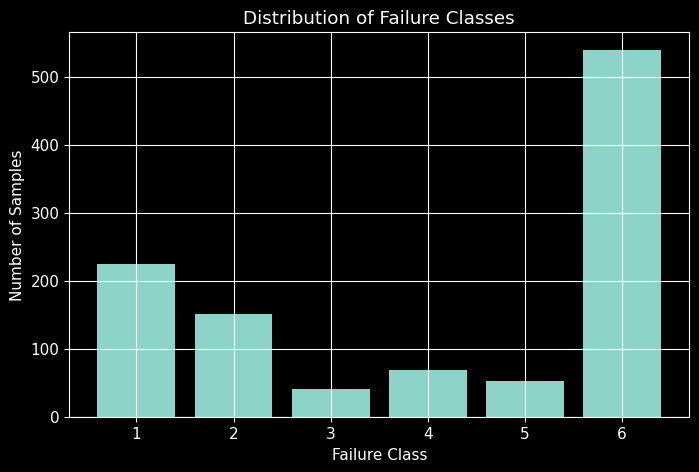

In [ ]:
class_counts = model_df["Label"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(
    class_counts.index.astype(str),
    class_counts.values
)

plt.title("Distribution of Failure Classes")

plt.xlabel("Failure Class")

plt.ylabel("Number of Samples")

plt.show()

## Visualization 2: Confusion Matrix

The confusion matrix summarizes the classification performance of the Gaussian Naïve Bayes classifier by comparing the predicted failure classes with the actual classes.

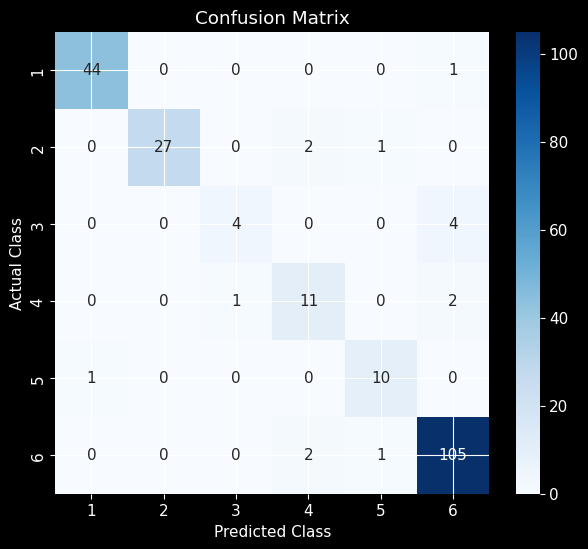

In [ ]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=sorted(model_df["Label"].unique()),
    yticklabels=sorted(model_df["Label"].unique())
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.show()

## Visualization 3: Actual vs Predicted Class Distribution

The following chart compares the distribution of the actual failure classes with the classes predicted by the Gaussian Naïve Bayes classifier.

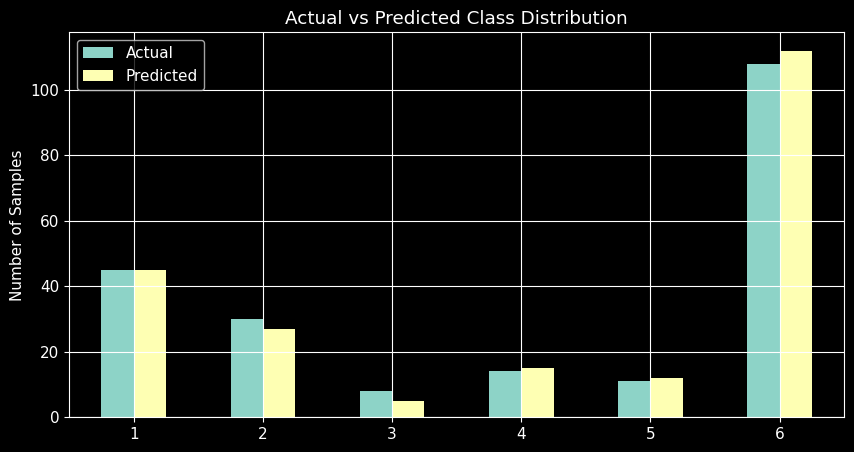

In [ ]:
actual_counts = pd.Series(y_test).value_counts().sort_index()
predicted_counts = pd.Series(predictions).value_counts().sort_index()

comparison = pd.DataFrame({
    "Actual": actual_counts,
    "Predicted": predicted_counts
}).fillna(0)

comparison.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Actual vs Predicted Class Distribution")

plt.ylabel("Number of Samples")

plt.xticks(rotation=0)

plt.show()

## Visualization 4: Prediction Probability Heatmap

Gaussian Naïve Bayes estimates the probability of each observation belonging to every failure class. The following heatmap displays the prediction probabilities for the first twenty testing samples.

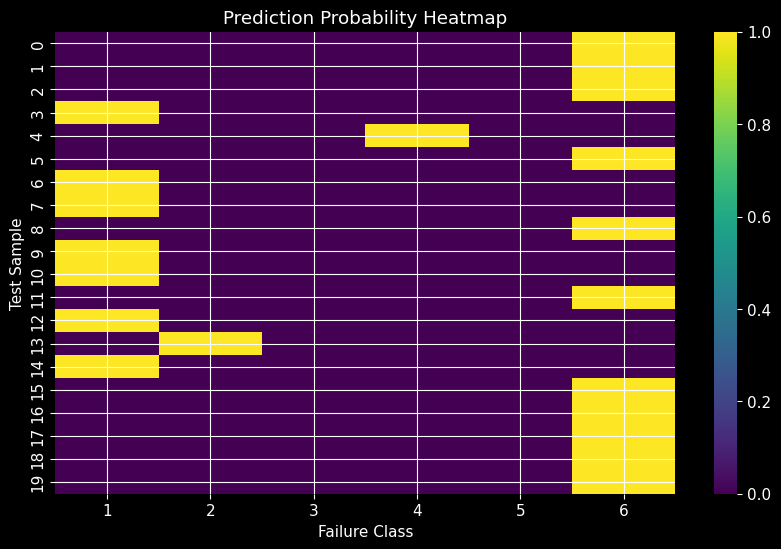

In [ ]:
probability_df = pd.DataFrame(
    probabilities[:20],
    columns=gnb.classes_
)

plt.figure(figsize=(10,6))

sns.heatmap(
    probability_df,
    cmap="viridis"
)

plt.title("Prediction Probability Heatmap")

plt.xlabel("Failure Class")

plt.ylabel("Test Sample")

plt.show()

## Visualization 5: Performance Summary

The following chart summarizes the overall performance of the Gaussian Naïve Bayes classifier using the selected evaluation metrics.

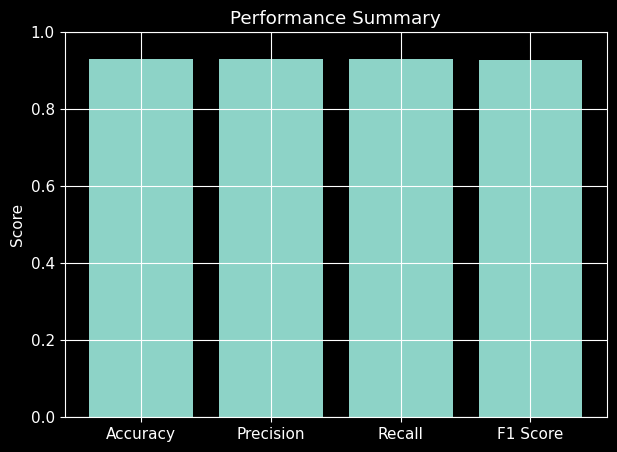

In [ ]:
plt.figure(figsize=(7,5))

plt.bar(
    evaluation["Metric"],
    evaluation["Score"]
)

plt.ylim(0,1)

plt.title("Performance Summary")

plt.ylabel("Score")

plt.show()

## Interpretation

The Gaussian Naïve Bayes classifier successfully classified cloud infrastructure failure events using probabilistic reasoning. Feature selection significantly improved the classifier by reducing the original feature space from 208 engineered features to the 50 most informative features. The confusion matrix, classification report, and evaluation metrics demonstrate that Gaussian Naïve Bayes achieved high predictive performance while maintaining computational efficiency for multi-class cloud failure classification.

## Conclusion

In this laboratory experiment, Gaussian Naïve Bayes was successfully implemented for multi-class cloud infrastructure failure classification. ANOVA-based feature selection was used to identify the most informative cloud monitoring features before model training, resulting in a significant improvement in predictive performance. The classifier was evaluated using weighted classification metrics, a confusion matrix, and probability-based visualizations, demonstrating the effectiveness of probabilistic machine learning for real-world cloud infrastructure monitoring datasets.

In [ ]:
checklist = pd.DataFrame({
    "Task":[
        "Loaded Dataset B",
        "Merged features and labels",
        "Prepared multi-class dataset",
        "Applied feature selection",
        "Implemented Gaussian Naïve Bayes",
        "Evaluated the classifier",
        "Generated visualizations",
        "Interpreted probabilistic predictions",
        "Completed experiment"
    ],
    "Status":["✓ Completed"]*9
})

display(checklist)

,Task,Status
0,Loaded Dataset B,✓ Completed
1,Merged features and labels,✓ Completed
2,Prepared multi-class dataset,✓ Completed
3,Applied feature selection,✓ Completed
4,Implemented Gaussian Naïve Bayes,✓ Completed
5,Evaluated the classifier,✓ Completed
6,Generated visualizations,✓ Completed
7,Interpreted probabilistic predictions,✓ Completed
8,Completed experiment,✓ Completed
